### Vertical land motion from a single viewing geometry

This notebook turns Venti's calibrated displacement into vertical land motion (VLM)
for New York City (OPERA DISP-S1 frame F08622, 208 products, 2016-2023) and checks
it against independent GNSS. It follows the method of the NYC calibration report
(run 4: RMSE 1.68 mm/yr at 89 GNSS stations, with plate motion removed from the GNSS
reference before calibration). Here Venti calibrates in IGS20 and plate motion is
removed afterwards; the result at the same stations is RMSE 1.67 mm/yr.

**Why plate motion matters.** Venti calibrates InSAR to the UNR GNSS grid in IGS20,
so the calibrated LOS velocity contains *horizontal* motion as well, and at NYC most
of it is the rigid rotation of the North American plate (about 16 mm/yr to the
west, 4 mm/yr to the north). Seen in the LOS this is 7-10 mm/yr, so `LOS / los_up`
would be off by about 10 mm/yr.

With one geometry the horizontal part has to come from a model. Here it is the
rigid North American (NOAM) plate rotation of the ITRF2020 plate motion model:

$$v_{up} \approx \frac{v_{LOS} - (e\,v_E^{plate} + n\,v_N^{plate})}{u}$$

where $e, n, u$ are the LOS unit-vector components of each pixel. What remains
after removing the plate rotation (intraplate horizontal motion) is well under
1 mm/yr at NYC, which this notebook checks at the GNSS stations.

Steps:
1. Calibrate all 208 products with Venti (IGS20, tropospheric and solid Earth tide
   corrections).
2. Build the calibrated LOS displacement series and fit a LOS velocity per pixel
   (180 m grid).
3. Compute the plate-motion LOS field per pixel and remove it.
4. Divide by `los_up` and validate against MIDAS vertical rates at the GNSS stations.

The validation is independent of the calibration: Venti uses the UNR *gridded*
velocity product, while the check uses MIDAS trends (Blewitt et al. 2016,
https://doi.org/10.1002/2015JB012552) fit here to each station's raw UNR position
series with `geepers`.

In [ ]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from geepers.euler import EulerPole, predict_plate_motion, rotation_vector_to_pole
from geepers.gps_sources.unr import UnrSource
from geepers.midas import midas
from pyproj import Transformer
from rasterio.warp import transform_bounds

import venti
from venti.io.raster import read_netcdf
from venti.models.load_itrf import load_itrf_pmm
from venti.spatial import downsample_array, grid_coordinates
from venti.workflow.calibration import CalibrationWorkflow
from venti.workflow.config import (
    AlgorithmParameters,
    CalibrationInputGroup,
    CalibrationOptions,
    ProcessingOptions,
    ProductPathGroup,
    RunConfig,
    VentiConfig,
)
from venti.workflow.utils import get_file_dates

venti.configure_logging()

/home/cabrera/python/miniconda3/envs/venti/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Logger venti (INFO)>

### 1. Calibrate every product

Same settings as `calibration_workflow.ipynb`. Calibrating 208 products takes about
2-5 hours, so `run()` is only called when surfaces are missing (it recalibrates every
product in `input_files`). The run used here was made with the same configuration by
a batch script (`calibrate_all_products.py` in the output folder), equivalent to
`venti run --config-file runconfig.yaml --n-workers 6`.

In [ ]:
frame_dir = Path("/mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/frame_08622")
output_dir = Path("/mnt/aurora-z0/cabrera/opera_vlm/data/nyc_08622/notebook_examples")
FACTOR = 6        # 30 m -> 180 m grid for the velocity fit
LOS_UP_MIN = 0.3  # skip pixels where the geometry is nearly horizontal

los_file = frame_dir / "los" / "los_enu_frame_8622.tif"
water_mask_file = frame_dir / "water_mask.tif"
config = VentiConfig(
    run_config=RunConfig(
        calibration_input_group=CalibrationInputGroup(
            input_files=frame_dir / "disp_s1",
            los_file=los_file,
            water_mask=water_mask_file,
            tropo_files=frame_dir / "tropo" / "tropo_corrections_32618",
        ),
        product_path_group=ProductPathGroup(
            product_path=output_dir / "calibrated",
            scratch_path=output_dir / "scratch",
        ),
    ),
    algorithm_parameters=AlgorithmParameters(
        processing_options=ProcessingOptions(cal_downsample_factor=6),
        calibration_options=CalibrationOptions(
            grid_type="constant",
            window_size_meters=30_000,
            posting_meters=30,
            recompute_gnss=False,
        ),
    ),
)

products = sorted((frame_dir / "disp_s1").glob("*.nc"))
suffix = "_calibration_surface_constant_igs20_downsample6_tropo_set.tif"
surfaces = {p.stem: output_dir / "calibrated" / f"{p.stem}{suffix}" for p in products}
missing = [p for p in products if not surfaces[p.stem].exists()]
if missing:
    state = CalibrationWorkflow(config=config).run(n_workers=6)
    print(f"calibrated {state.n_files_processed} products, {state.n_files_failed} failed")
print(f"{len(products)} products, {len(products) - len(missing)} calibration surfaces found")

208 products, 208 calibration surfaces found


### 2. Calibrated displacement series and LOS velocity

OPERA products are grouped by reference date (a new reference about every 6 months),
and each group's last product ends on the next group's reference date. Adding each
calibrated product to the cumulative displacement at its reference date stitches the
groups into one series from 2016-07-16. Calibrated products are already tied to
GNSS, so no reference pixel is needed.

Reading 208 full-resolution products takes a while (about 30-80 minutes depending
on disk load), so the 180 m series is cached.

In [ ]:
with rasterio.open(water_mask_file) as src:
    mask = src.read(1).astype(bool)


def calibrated_step(product):
    """Calibrated displacement (mm) of one product on the 180 m grid."""
    disp = read_netcdf(product, variable="displacement")[0]
    with rasterio.open(surfaces[product.stem]) as src:
        calibrated = np.where(mask, disp - src.read(1), np.nan)
    return downsample_array(calibrated, FACTOR).astype("float32") * 1000


series_file = output_dir / f"calibrated_los_series_ds{FACTOR}.npz"
if series_file.exists():
    cached = np.load(series_file)
    years, series = cached["years"], cached["series"]
else:
    with ThreadPoolExecutor(4) as pool:
        steps = pool.map(calibrated_step, products)
        cumulative, dates = {}, {}
        for product, step in zip(products, steps):  # sorted by (reference, secondary)
            ref, sec = product.name.split("_")[6:8]
            t_ref, t_sec = get_file_dates(product)
            if not cumulative:
                cumulative[ref], dates[ref] = np.zeros_like(step), t_ref
            cumulative[sec], dates[sec] = cumulative[ref] + step, t_sec
    keys = sorted(cumulative)
    years = np.array([dates[k] for k in keys])
    series = np.stack([cumulative[k] for k in keys])
    np.savez(series_file, years=years, series=series)


def fit_velocity(t, series, min_dates=20):
    """Least-squares slope per pixel, using each pixel's own valid dates."""
    valid = np.isfinite(series)
    n = valid.sum(0)
    tt = np.where(valid, t[:, None, None], 0.0)
    yy = np.where(valid, series, 0.0)
    st, stt, sy, sty = tt.sum(0), (tt * tt).sum(0), yy.sum(0), (tt * yy).sum(0)
    denom = n * stt - st**2
    with np.errstate(invalid="ignore", divide="ignore"):
        slope = (n * sty - st * sy) / denom
    return np.where((n >= min_dates) & (denom > 0), slope, np.nan)


v_los = fit_velocity(years - years[0], series)
print(f"{years.size} dates over {years[-1] - years[0]:.1f} years; "
      f"median LOS velocity {np.nanmedian(v_los):+.1f} mm/yr")

209 dates over 7.3 years; median LOS velocity +7.8 mm/yr


### 3. Plate motion in the line of sight

The ITRF2020 plate motion model gives the NOAM rotation as a rotation vector
(`omega_x, omega_y, omega_z` in deg/Myr). `geepers.euler` turns it into an Euler pole
and predicts the east and north plate velocity at every grid cell.

The projection has to be done **per pixel**. The plate velocity itself changes
little across one frame, but the look direction does: the incidence angle goes from
about 31 to 46 degrees across the swath, so `los_east` goes from -0.50 to -0.71. A
single frame-center value (9.0 mm/yr) put a false 3 mm/yr west-east ramp into an
earlier NYC run (RMSE 2.03 -> 1.68 mm/yr once fixed).

The LOS raster fills pixels outside the swath with `(e, n, u) = (0, 0, 1)` instead of
NaN, so those pixels are set to NaN before averaging to the 180 m grid; otherwise the
plate field would drop toward 0 near the swath edges.

In [ ]:
with rasterio.open(los_file) as src:
    los_east, los_north, los_up = src.read().astype("float64")
    los_crs = src.crs
outside_swath = (los_east == 0) & (los_north == 0)
e, n, u = (
    downsample_array(np.where(outside_swath, np.nan, c), FACTOR)
    for c in (los_east, los_north, los_up)
)

x, y = grid_coordinates(products[0])
x_ds = x[: x.size // FACTOR * FACTOR].reshape(-1, FACTOR).mean(1)
y_ds = y[: y.size // FACTOR * FACTOR].reshape(-1, FACTOR).mean(1)
lon, lat = Transformer.from_crs(los_crs, "EPSG:4326", always_xy=True).transform(
    *np.meshgrid(x_ds, y_ds)
)

noam = load_itrf_pmm(date=2020).set_index("plate").loc["NOAM"]
omega_rad_yr = np.radians(noam[["omega_x", "omega_y", "omega_z"]].to_numpy(float)) / 1e6
pole = EulerPole(*rotation_vector_to_pole(omega_rad_yr))
ve_plate, vn_plate = (
    v.reshape(lon.shape) for v in predict_plate_motion(pole, lon.ravel(), lat.ravel())
)
plate_los = e * ve_plate + n * vn_plate

print(f"NOAM pole: lon {pole.lon:.1f}, lat {pole.lat:.1f} deg")
print(f"plate velocity: east {np.median(ve_plate):+.1f}, north {np.median(vn_plate):+.1f} mm/yr")
print(f"plate motion in LOS: {np.nanmin(plate_los):.1f} to {np.nanmax(plate_los):.1f} mm/yr")

NOAM pole: lon -86.1, lat -8.3 deg
plate velocity: east -15.4, north +4.4 mm/yr
plate motion in LOS: 7.2 to 10.5 mm/yr


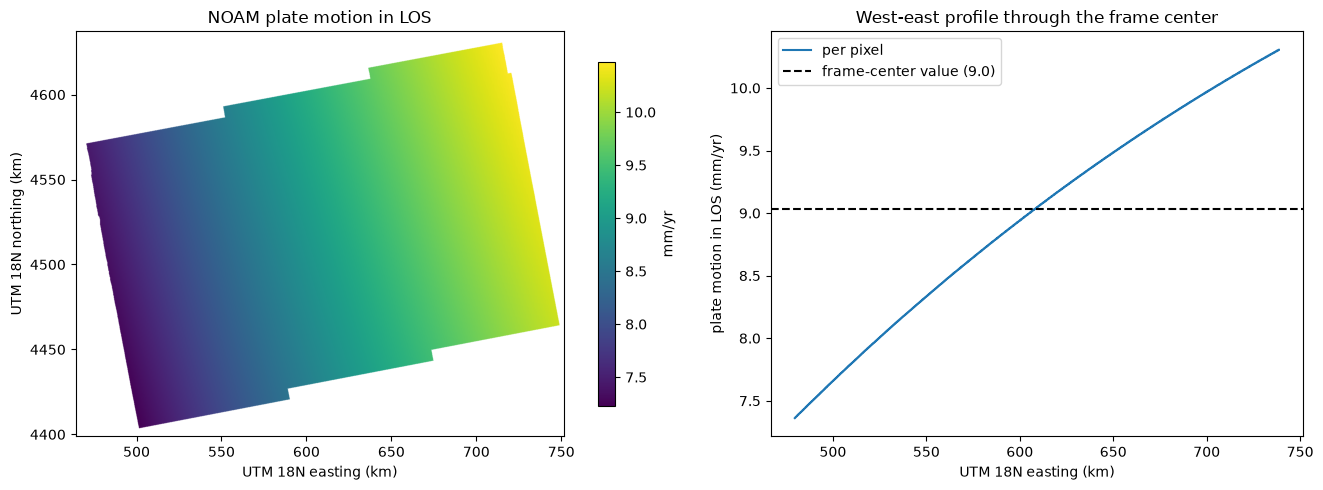

In [ ]:
extent_km = np.array([x_ds[0], x_ds[-1], y_ds[-1], y_ds[0]]) / 1000
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.3, 1]})
im = axes[0].imshow(plate_los, cmap="viridis", extent=extent_km)
fig.colorbar(im, ax=axes[0], shrink=0.85, label="mm/yr")
axes[0].set_title("NOAM plate motion in LOS")
axes[0].set_xlabel("UTM 18N easting (km)")
axes[0].set_ylabel("UTM 18N northing (km)")

row = plate_los.shape[0] // 2
center = plate_los[row, np.nanargmin(np.abs(x_ds - x_ds.mean()))]
axes[1].plot(x_ds / 1000, plate_los[row], label="per pixel")
axes[1].axhline(center, color="k", ls="--", label=f"frame-center value ({center:.1f})")
axes[1].set_xlabel("UTM 18N easting (km)")
axes[1].set_ylabel("plate motion in LOS (mm/yr)")
axes[1].set_title("West-east profile through the frame center")
axes[1].legend()
plt.tight_layout()
plt.show()

### 4. Vertical velocity and validation against GNSS

MIDAS east, north and up rates are fit to every UNR station in the frame with at
least 2 years of data. Each station is compared with the 180 m cell that contains
it. `LOS / u` without removing plate motion is shown for contrast.

In [ ]:
usable = np.isfinite(v_los) & (u > LOS_UP_MIN)
v_up = np.where(usable, (v_los - plate_los) / u, np.nan)
v_naive = np.where(usable, v_los / u, np.nan)  # plate motion left in


def midas_rates(bbox, min_span_years=2.0):
    """MIDAS east/north/up rates (mm/yr, IGS20) of the UNR stations in a bbox."""
    gps = UnrSource().timeseries_many(bbox=bbox, frame="ENU", zero_by="mean")
    rows = {}
    for station, df in gps.groupby("id"):
        span = (df["date"].max() - df["date"].min()).days / 365.25
        if span < min_span_years:
            continue
        t = (df["date"] - df["date"].iloc[0]).dt.days.to_numpy() / 365.25
        row = {"lon": df["lon"].iloc[0], "lat": df["lat"].iloc[0], "span_years": span}
        for component in ("east", "north", "up"):
            fit = midas(t, df[component].to_numpy())
            row[f"v{component[0]}"] = fit.velocity * 1000
            row[f"sigma_v{component[0]}"] = fit.velocity_uncertainty * 1000
        rows[station] = row
    return pd.DataFrame.from_dict(rows, orient="index").dropna()


def sample(grid, lon, lat):
    """Value of the 180 m cell containing each lon/lat (NaN outside the grid)."""
    sx, sy = Transformer.from_crs("EPSG:4326", los_crs, always_xy=True).transform(lon, lat)
    step = x_ds[1] - x_ds[0]
    cols = np.floor((sx - x_ds[0] + step / 2) / step).astype(int)
    rows = np.floor((y_ds[0] + step / 2 - sy) / step).astype(int)
    inside = (rows >= 0) & (rows < y_ds.size) & (cols >= 0) & (cols < x_ds.size)
    values = grid[np.where(inside, rows, 0), np.where(inside, cols, 0)]
    return np.where(inside, values, np.nan)


with rasterio.open(water_mask_file) as src:
    bbox = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
gnss = midas_rates(bbox)
lon_st, lat_st = gnss["lon"].to_numpy(), gnss["lat"].to_numpy()
gnss["insar_up"] = sample(v_up, lon_st, lat_st)
gnss["insar_naive"] = sample(v_naive, lon_st, lat_st)
gnss = gnss.dropna(subset=["insar_up"])

# Horizontal motion left after removing the plate rotation, as seen in the LOS.
e_st, n_st = sample(e, gnss["lon"], gnss["lat"]), sample(n, gnss["lon"], gnss["lat"])
intraplate_los = (
    e_st * (gnss["ve"] - sample(ve_plate, gnss["lon"], gnss["lat"]))
    + n_st * (gnss["vn"] - sample(vn_plate, gnss["lon"], gnss["lat"]))
)


def stats(insar, gps):
    diff = insar - gps
    return {
        "n": diff.size,
        "bias": diff.mean(),
        "MAD": 1.4826 * np.median(np.abs(diff - np.median(diff))),
        "RMSE": np.sqrt((diff**2).mean()),
    }


table = pd.DataFrame({
    "(LOS - plate) / u": stats(gnss["insar_up"], gnss["vu"]),
    "LOS / u (plate left in)": stats(gnss["insar_naive"], gnss["vu"]),
}).T
print(f"{len(gnss)} GNSS stations; intraplate horizontal motion in LOS: "
      f"median {intraplate_los.median():+.2f}, std {intraplate_los.std():.2f} mm/yr")
print(f"median vertical velocity: {np.nanmedian(v_up):+.2f} mm/yr")
table.round(2)


Loading GPS data:   0%|          | 0/126 [00:00<?, ?it/s]


Loading GPS data:   1%|          | 1/126 [00:00<00:24,  5.02it/s]


Loading GPS data:   7%|▋         | 9/126 [00:00<00:04, 27.59it/s]


Loading GPS data:  10%|█         | 13/126 [00:00<00:03, 30.53it/s]


Loading GPS data:  15%|█▌        | 19/126 [00:00<00:03, 34.98it/s]

...


Loading GPS data:  94%|█████████▍| 119/126 [00:03<00:00, 38.51it/s]


Loading GPS data: 100%|██████████| 126/126 [00:03<00:00, 44.75it/s]


Loading GPS data: 100%|██████████| 126/126 [00:03<00:00, 36.87it/s]

89 GNSS stations; intraplate horizontal motion in LOS: median -0.21, std 0.56 mm/yr
median vertical velocity: -0.85 mm/yr


,n,bias,MAD,RMSE
(LOS - plate) / u,89.0,0.58,1.11,1.67
LOS / u (plate left in),89.0,11.76,2.33,12.09


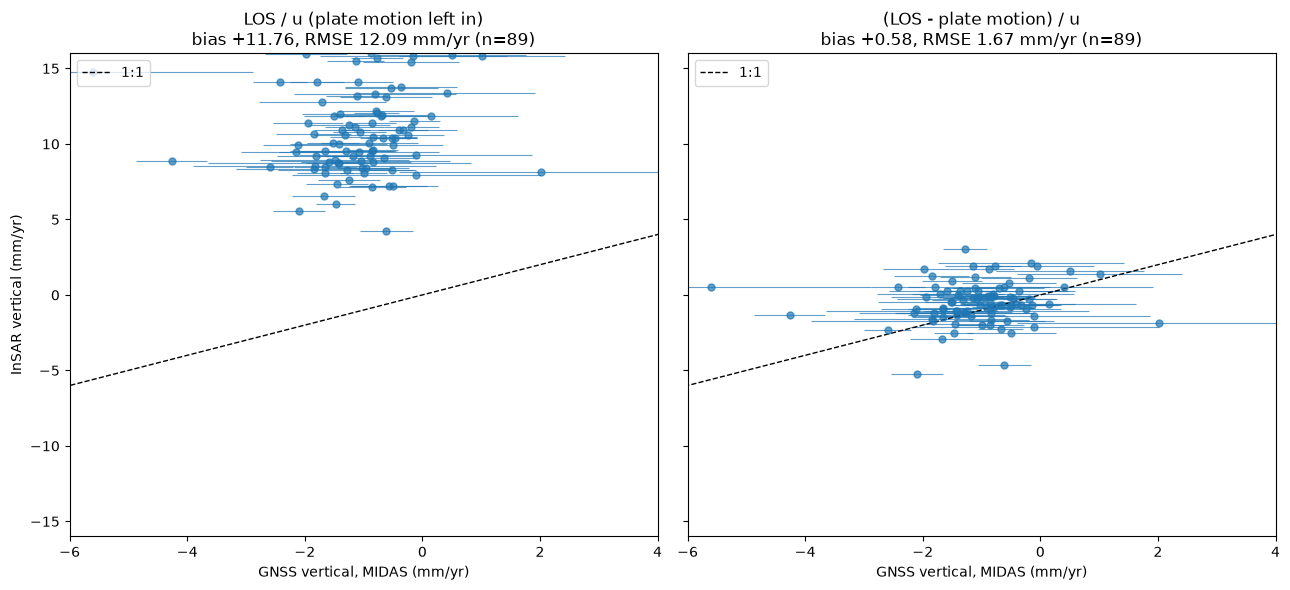

In [ ]:
lim = (-16, 16)
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, column, label in [
    (axes[0], "insar_naive", "LOS / u (plate motion left in)"),
    (axes[1], "insar_up", "(LOS - plate motion) / u"),
]:
    s = stats(gnss[column], gnss["vu"])
    ax.errorbar(gnss["vu"], gnss[column], xerr=gnss["sigma_vu"], fmt="o", ms=5,
                alpha=0.7, elinewidth=0.8)
    ax.plot(lim, lim, "k--", lw=1, label="1:1")
    ax.set_xlim(-6, 4)
    ax.set_ylim(*lim)
    ax.set_title(f"{label}\nbias {s['bias']:+.2f}, RMSE {s['RMSE']:.2f} mm/yr (n={s['n']})")
    ax.set_xlabel("GNSS vertical, MIDAS (mm/yr)")
    ax.legend(loc="upper left")
axes[0].set_ylabel("InSAR vertical (mm/yr)")
plt.tight_layout()
plt.show()

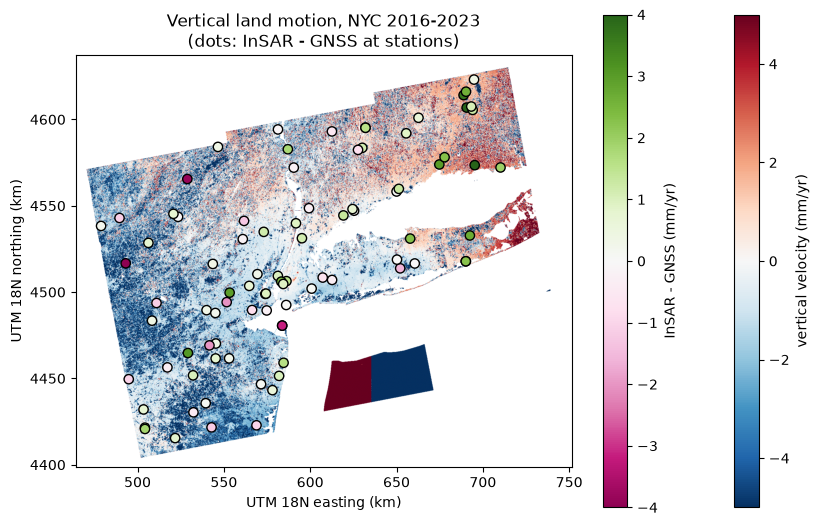

largest residuals (mm/yr):
CTMI    6.14
CTGU    4.34
NJWC   -4.03
WGNJ   -3.86
BGI1    3.67
dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(v_up, cmap="RdBu_r", vmin=-5, vmax=5, extent=extent_km)
fig.colorbar(im, ax=ax, shrink=0.8, label="vertical velocity (mm/yr)")
sx, sy = Transformer.from_crs("EPSG:4326", los_crs, always_xy=True).transform(
    gnss["lon"], gnss["lat"]
)
residual = gnss["insar_up"] - gnss["vu"]
pts = ax.scatter(np.asarray(sx) / 1000, np.asarray(sy) / 1000, c=residual, cmap="PiYG",
                 vmin=-4, vmax=4, edgecolors="k", s=45)
fig.colorbar(pts, ax=ax, shrink=0.8, label="InSAR - GNSS (mm/yr)")
ax.set_title("Vertical land motion, NYC 2016-2023\n(dots: InSAR - GNSS at stations)")
ax.set_xlabel("UTM 18N easting (km)")
ax.set_ylabel("UTM 18N northing (km)")
plt.show()

print("largest residuals (mm/yr):")
print(residual.reindex(residual.abs().sort_values(ascending=False).index).head(5).round(2))